Rathan N Gowda

In [ ]:





import tensorflow as tf
mist=tf.keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("Train images shapes:",x_train.shape)
print("Test images shapes:",x_test.shape)
print("Train labels shapes:",y_train.shape)
print("Test labels shapes:",y_test.shape)

Train images shapes: (60000, 28, 28)
Test images shapes: (10000, 28, 28)
Train labels shapes: (60000,)
Test labels shapes: (10000,)


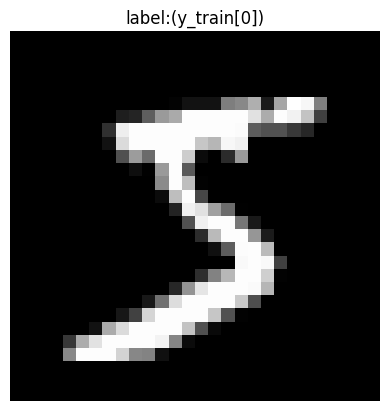

In [ ]:
import matplotlib.pyplot as plt
#plot first images
plt.imshow(x_train[0],cmap='grey')
plt.title(f"label:(y_train[0])")   #show the label
plt.axis('off')
plt.show()

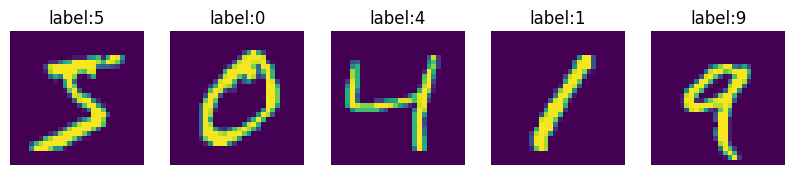

In [ ]:
#show first 5 images
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i])
    plt.title(f"label:{y_train[i]}")
    plt.axis('off')
plt.show()

In [ ]:
#normalise values(0 to 1)
x_train=x_train/255.0
x_test=x_test/255.0

In [ ]:
#add channel dimension (important for CNN)
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))

In [ ]:
from tensorflow.keras import layers,models
model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax'),

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#compile method
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
#step6:Train model
model.fit(x_train, y_train, epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - accuracy: 0.8733 - loss: 0.4082
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9365 - loss: 0.2118
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.9576 - loss: 0.1433


In [ ]:
#step 7:test model
test_loss, test_acc = model.evaluate(x_test,y_test)
print("Accuracy",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9660 - loss: 0.1116
Accuracy 0.9660000205039978


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Original Label: 2
Predicted Label: 2


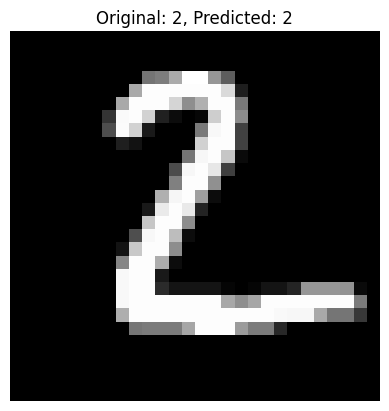

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random index
index = np.random.randint(0, len(x_test))

# Get image and label
sample_image = x_test[index]
true_label = y_test[index]

# Expand dimensions for model input
sample_image_input = np.expand_dims(sample_image, axis=0)

# Predict
prediction = model.predict(sample_image_input)    # gives probability from 0 to 9
predicted_label = np.argmax(prediction)           # gives the index of highest probability

# Print results
print("Original Label:", true_label)
print("Predicted Label:", predicted_label)

# Show the image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Original: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [ ]:
# Step 4: Build CNN model

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),   #convolution layer 2
    tf.keras.layers.MaxPooling2D(2,2),   #pooling layer 2

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')])

# Step 5: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train model
model.fit(x_train, y_train, epochs=3)
#print(model.summary())

# Step 7: Test model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.6160 - loss: 1.1311
Epoch 2/3
 390/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.8678 - loss: 0.4472


KeyboardInterrupt

